UNIVERSIDADE PRESBITERIANA MACKENZIE Faculdade de Computação e Informática Disciplina: Inteligência Artificial Professor: Dr. Ivan Carlos Alcântara de Oliveira

MEMBROS DO GRUPO:

Rafael Moutinho Tessarotto - 10395682
Edson Fu - 10419137
Rafael Santos Lourenço da Silva - 10403588
SÍNTESE DO CONTEÚDO: Análise exploratória do dataset de sintomas e testes de extração de entidades utilizando LLM para o Sistema Inteligente de Pré-Triagem.

HISTÓRICO DE ALTERAÇÕES:

Data	Autor	Descrição
01/04/2026	Rafael Tessarotto	Estrutura inicial e carregamento do dataset.
[Data]	[Nome]	Implementação da limpeza de texto e EDA.
'''

Esse é o arquivo que tem que estar no topo dos códigos, alterações tem que ser feitas pelo que eu entendi

Index(['wartezeit_S', 'triagestufe', 'wartezeit_m', 't1', 't2', 't3', 't4',
       't5', 'patienten'],
      dtype='object')
Pré-visualização:
   wartezeit_S  triagestufe  wartezeit_m           t1           t2  \
0        65251            5  1087,516667          0,2  185,1166667   
1        63488            5  1058,133333         0,15  184,4166667   
2        60458            5  1007,633333  0,133333333  178,9333333   
3        60048            5       1000,8  0,133333333  175,3666667   
4        57906            5        965,1  0,116666667  158,9333333   

            t3           t4           t5  patienten  
0  381,2666667        723,9  1087,516667    29564.0  
1  341,3833333  722,3833333  1058,133333        NaN  
2  323,9166667  719,8166667  1007,633333        NaN  
3          308  705,3666667       1000,8        NaN  
4  296,9166667       704,85        965,1        NaN  

Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29564 entries, 0 to 29563
Data columns (total 9 

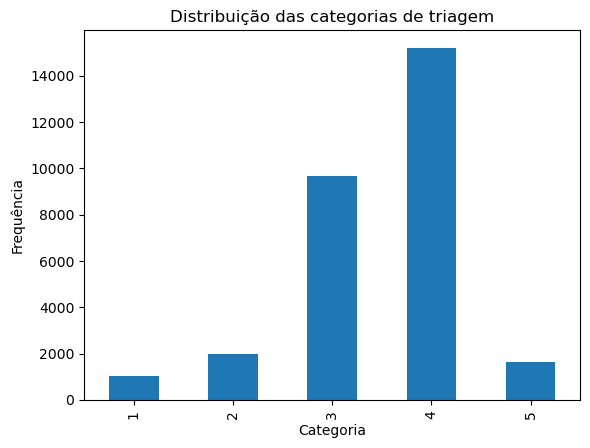

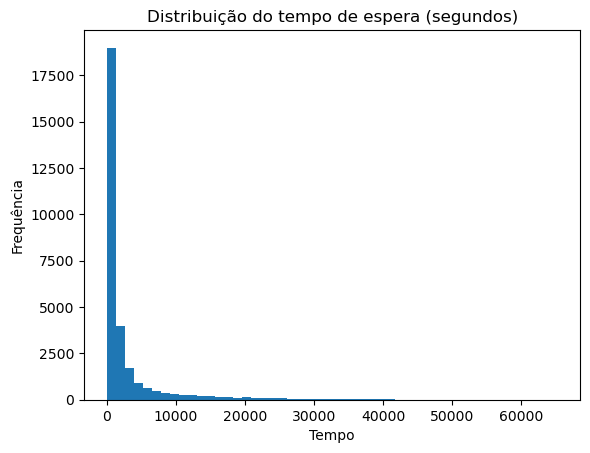


Tempo médio por categoria:
triagestufe
1       2.175000
2     879.389985
3    1238.542875
4    3590.067798
5    6484.024864
Name: wartezeit_S, dtype: float64


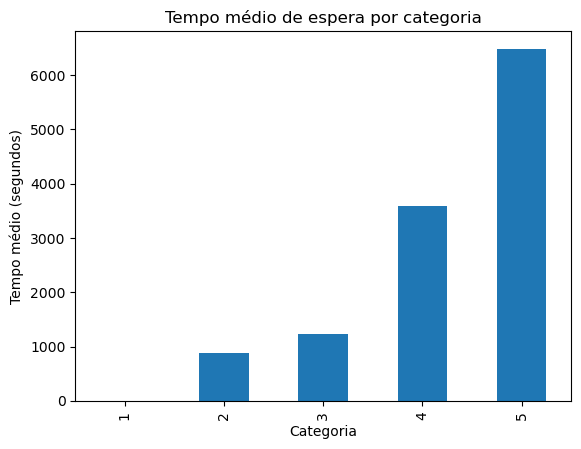

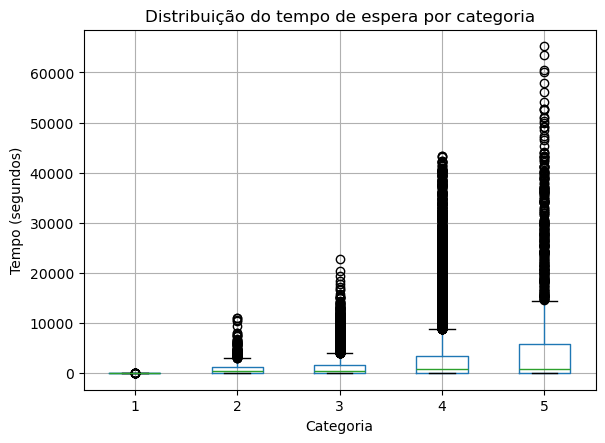


Quantidade de outliers: 296
   wartezeit_S  triagestufe  wartezeit_m           t1           t2  \
0        65251            5  1087,516667          0,2  185,1166667   
1        63488            5  1058,133333         0,15  184,4166667   
2        60458            5  1007,633333  0,133333333  178,9333333   
3        60048            5       1000,8  0,133333333  175,3666667   
4        57906            5        965,1  0,116666667  158,9333333   

            t3           t4           t5  patienten  
0  381,2666667        723,9  1087,516667    29564.0  
1  341,3833333  722,3833333  1058,133333        NaN  
2  323,9166667  719,8166667  1007,633333        NaN  
3          308  705,3666667       1000,8        NaN  
4  296,9166667       704,85        965,1        NaN  

Estatísticas por categoria:
                    mean  median  min    max           std
triagestufe                                               
1               2.175000     2.0    1     12      1.004394
2             879.38

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('durchlauf1.csv', sep=';', engine='python')
df.columns = df.columns.str.strip()

print(df.columns)

print("Pré-visualização:")
print(df.head())

print("\nInformações:")
print(df.info())

df['wartezeit_S'] = pd.to_numeric(df['wartezeit_S'], errors='coerce')
df = df.dropna(subset=['wartezeit_S', 'triagestufe'])

print("\nEstatísticas gerais:")
print(df.describe())

df['triagestufe'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribuição das categorias de triagem")
plt.xlabel("Categoria")
plt.ylabel("Frequência")
plt.show()

df['wartezeit_S'].plot(kind='hist', bins=50)
plt.title("Distribuição do tempo de espera (segundos)")
plt.xlabel("Tempo")
plt.ylabel("Frequência")
plt.show()

mean_wait = df.groupby('triagestufe')['wartezeit_S'].mean()

print("\nTempo médio por categoria:")
print(mean_wait)

mean_wait.plot(kind='bar')
plt.title("Tempo médio de espera por categoria")
plt.xlabel("Categoria")
plt.ylabel("Tempo médio (segundos)")
plt.show()

df.boxplot(column='wartezeit_S', by='triagestufe')
plt.title("Distribuição do tempo de espera por categoria")
plt.suptitle("")
plt.xlabel("Categoria")
plt.ylabel("Tempo (segundos)")
plt.show()

outliers = df[df['wartezeit_S'] > df['wartezeit_S'].quantile(0.99)]

print("\nQuantidade de outliers:", len(outliers))
print(outliers.head())

stats = df.groupby('triagestufe')['wartezeit_S'].agg(['mean', 'median', 'min', 'max', 'std'])

print("\nEstatísticas por categoria:")
print(stats)

stats.to_csv("estatisticas_por_categoria.csv")
print("\nArquivo 'estatisticas_por_categoria.csv' salvo com sucesso!")